In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score, r2_score
sns.set(style="whitegrid")


In [31]:

df = pd.read_csv('/content/Mall_Customers.csv')

print("First 5 rows:")
print(df.head())




First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [32]:
print("\nDataset Info:")
print(df.info())




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [33]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [34]:
df = df.drop('CustomerID', axis=1)
print("\nDataFrame after dropping 'CustomerID':")
print(df.head())


DataFrame after dropping 'CustomerID':
    Genre  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40


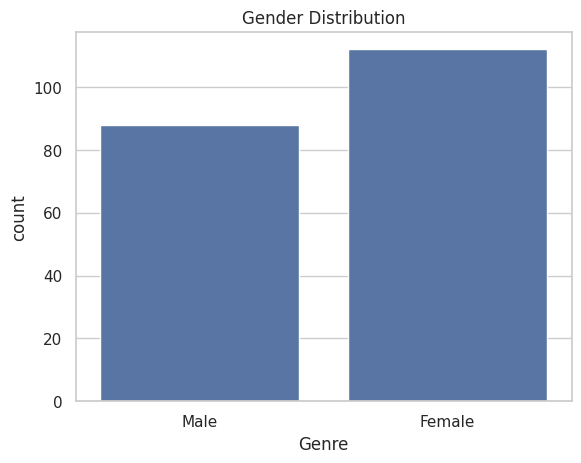

In [35]:

# Gender Distribution
plt.figure()
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

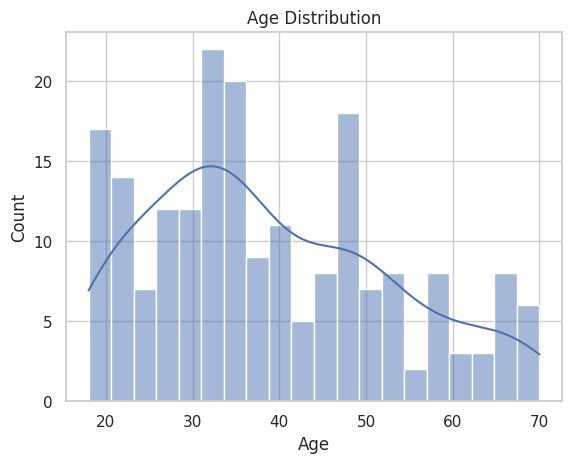

In [36]:

# Age Distribution
plt.figure()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

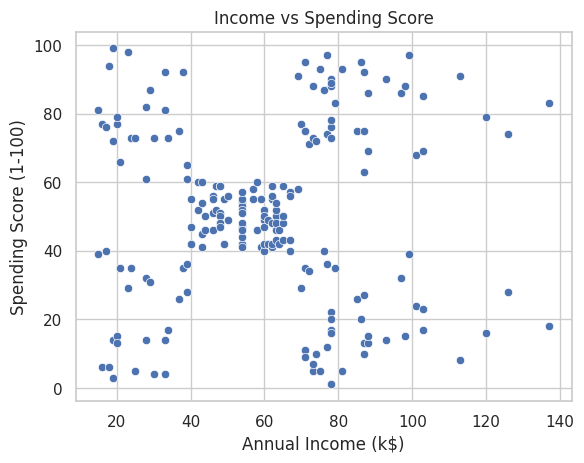

In [37]:

# Income vs Spending
plt.figure()
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

In [39]:
print("\nCorrelation Matrix of Numerical Features:")
print(df.corr(numeric_only=True))


Correlation Matrix of Numerical Features:
                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


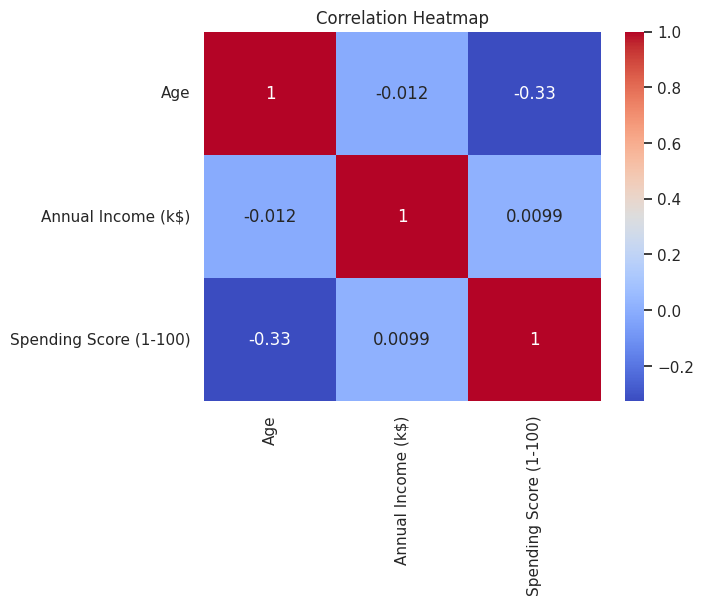

In [38]:
# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

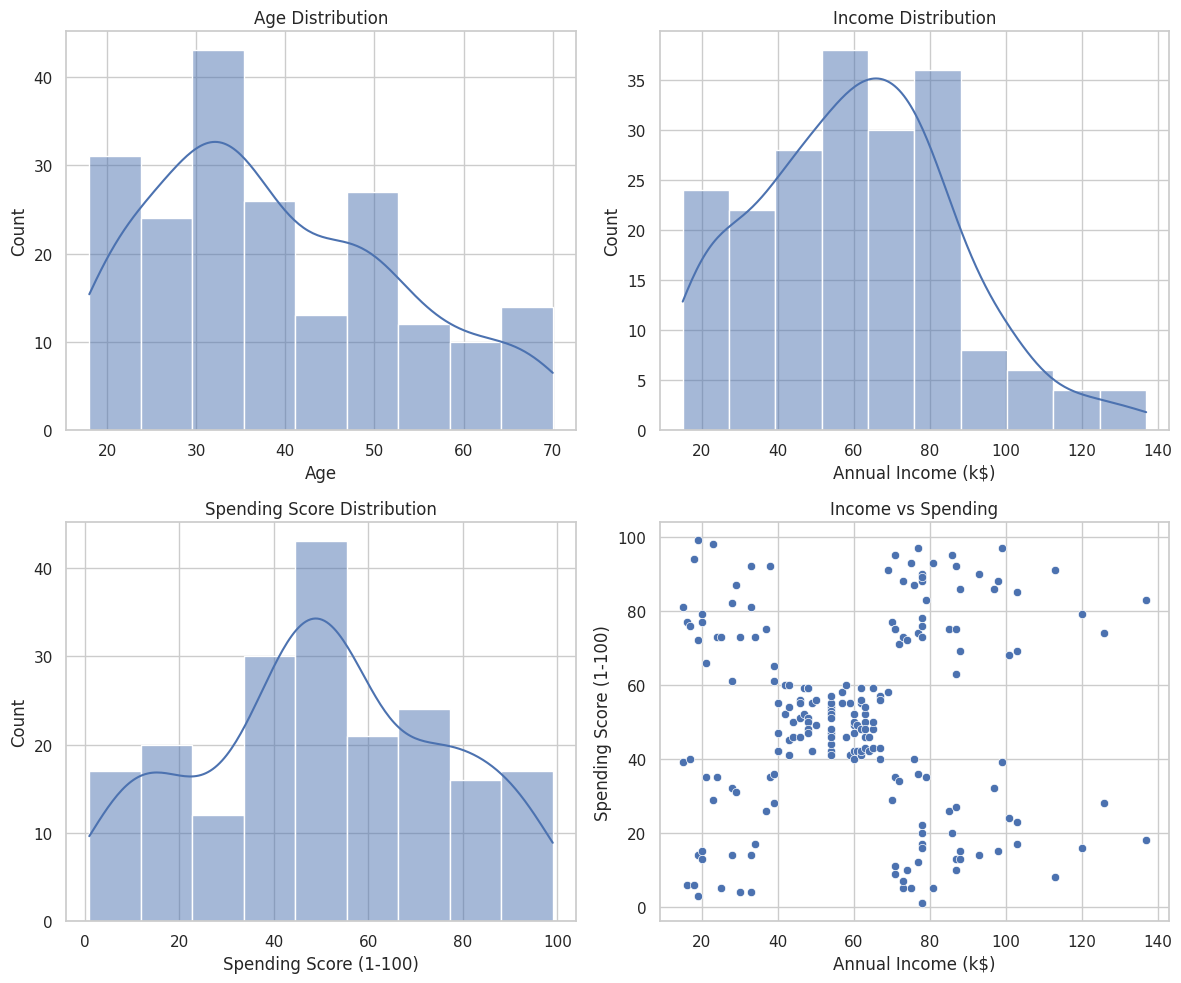

In [40]:
#multi plot dashboard view
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df['Age'], ax=axes[0,0], kde=True)
axes[0,0].set_title("Age Distribution")

sns.histplot(df['Annual Income (k$)'], ax=axes[0,1], kde=True)
axes[0,1].set_title("Income Distribution")

sns.histplot(df['Spending Score (1-100)'], ax=axes[1,0], kde=True)
axes[1,0].set_title("Spending Score Distribution")

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, ax=axes[1,1])
axes[1,1].set_title("Income vs Spending")

plt.tight_layout()
plt.show()


Explained Variance Ratio: [0.44266167 0.33308378]


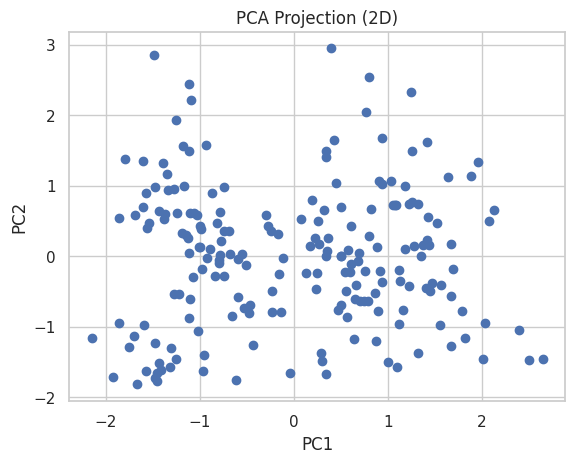

In [41]:

# DATA PREPROCESSING

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (DIMENSIONALITY REDUCTION)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


Regression R2 Score: 0.10711158828485168


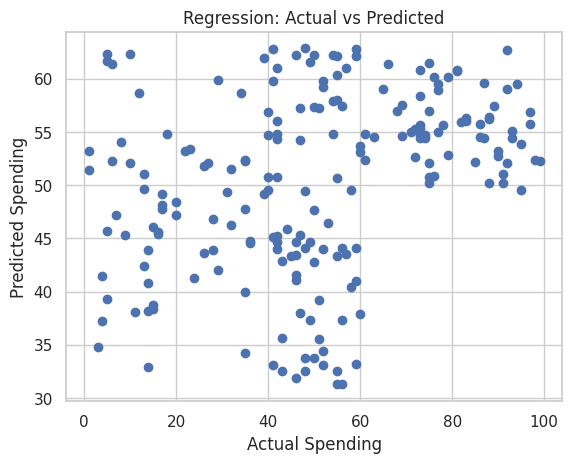

In [42]:

# REGRESSION (Predict Spending Score)

X_reg = df[['Age', 'Annual Income (k$)']] # independent variables
y_reg = df['Spending Score (1-100)'] #dependenet variable

model = LinearRegression()
model.fit(X_reg, y_reg)

y_pred = model.predict(X_reg)

print("\nRegression R2 Score:", r2_score(y_reg, y_pred))

plt.figure()
plt.scatter(y_reg, y_pred)
plt.xlabel("Actual Spending")
plt.ylabel("Predicted Spending")
plt.title("Regression: Actual vs Predicted")
plt.show()

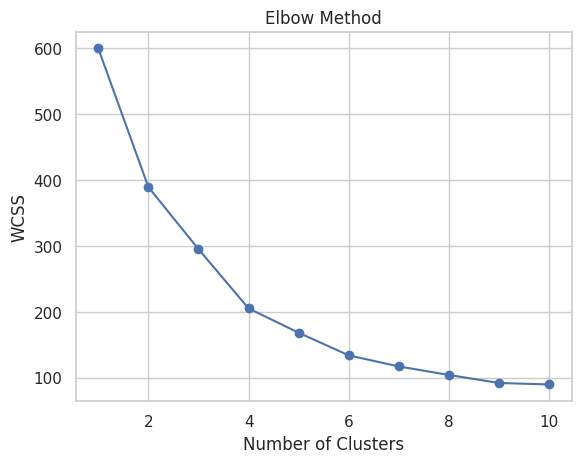

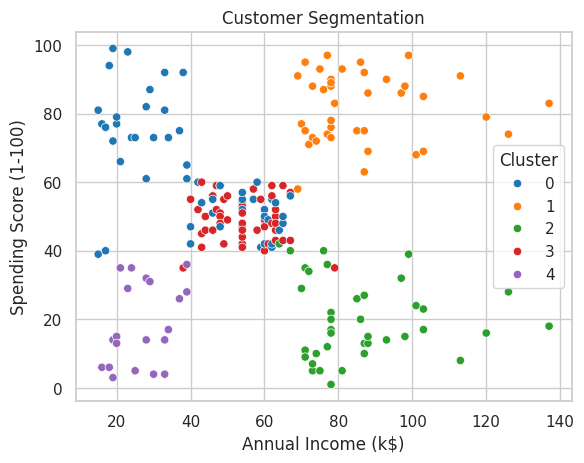


Silhouette Score: 0.41664341513732767

Pipeline Completed Successfully 🚀


In [43]:


# CLUSTERING K-MEANS


# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='random', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Final KMeans (choose k=5 typically)
kmeans = KMeans(n_clusters=5, init='random', n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Visualization
plt.figure()
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='tab10',
    data=df
)
plt.title("Customer Segmentation")
plt.show()

# Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("\nSilhouette Score:", score)

# =========================================================
# ✅ DONE
# =========================================================
print("\nPipeline Completed Successfully 🚀")


Iris Linear Regression R2 Score: 0.9286


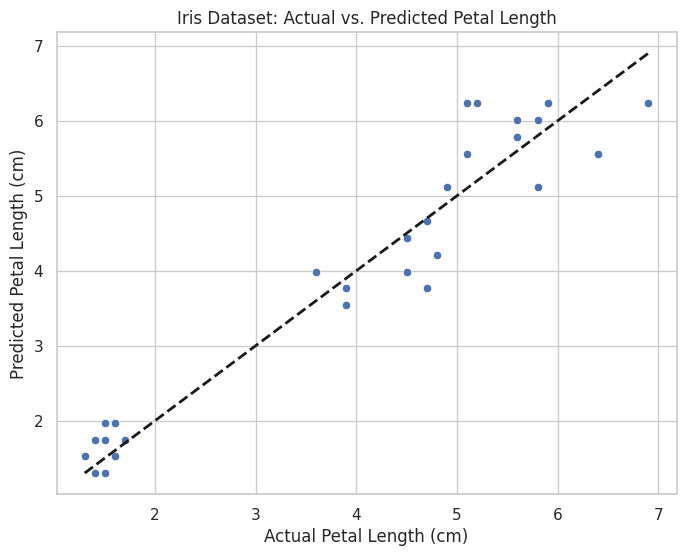

In [26]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

# For simplicity, let's try to predict 'petal length (cm)' using 'petal width (cm)'
X_iris = iris_df[['petal width (cm)']]
y_iris = iris_df['petal length (cm)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
iris_model = LinearRegression()
iris_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_iris = iris_model.predict(X_test)

# Evaluate the model
iris_r2_score = r2_score(y_test, y_pred_iris)
print(f"\nIris Linear Regression R2 Score: {iris_r2_score:.4f}")

# Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_iris)
plt.xlabel("Actual Petal Length (cm)")
plt.ylabel("Predicted Petal Length (cm)")
plt.title("Iris Dataset: Actual vs. Predicted Petal Length")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Add a diagonal line for reference
plt.show()